In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.size': 15, 'lines.linewidth': 2,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 1200,
})

import yaml
import numpy as np

import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

from irc.manager import IRCManager

from auditoryforage.utils import plot_AF_episode

/home/lokesh/anaconda3/envs/IRC/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Train one agent for a single environment

In [2]:
defaults = {
    'agent.env._target_': 'auditoryforage.AF_env.AuditoryForaging',
    'agent.model._target_': 'irc.model.FuncBeliefModel',
}
manager = IRCManager(defaults=defaults)

## Train an agent
We train a rational agent for the assume environment parameter [$lick\_cost, food\_reward, attention\_cost\_coeff, attention\_cost\_temp, penalty\_cost, iti\_cost$].

Checkpoint (epoch 369) loaded.
Fetching the most trained agent so far (epoch 369).
Agent (seed 0) was trained for 369 epochs, RL optimality 96.83%.


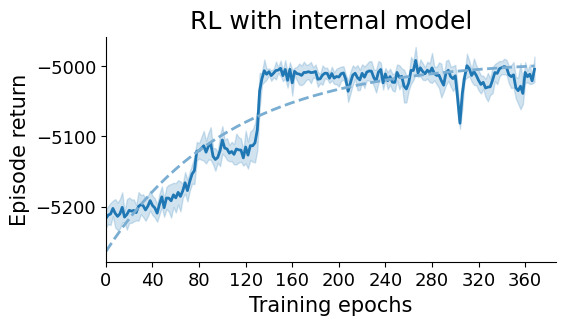

In [3]:
env_param = [-3.0, 200.0, .08, .25, -5000, 0]
num_epochs = 369

agent = manager.train_agent(env_param, num_epochs=num_epochs)
agent, fig = manager.inspect_agent(env_param, figsize=(5, 2.5))

## Run the agent in an environment
We create another environment which has the same observation space and action space as the assumed one, albeit with a different set of environment parameters.

problem somwhere here
[[3]
 [3]
 [3]
 ...
 [0]
 [0]
 [2]]
(array([2015]), array([0]))
problem somwhere here
[[3]
 [3]
 [3]
 ...
 [1]
 [1]
 [2]]
(array([2015]), array([0]))


{'agent': {'lick_cost': -3.0,
  'food_reward': 200.0,
  'attention_cost_coeff': 0.08,
  'attention_cost_temp': 0.25,
  'penalty_cost': -5000,
  'iti_cost': 0,
  'no_attention_modes': 6},
 'experiment': {'prob_01': 0.004,
  'no_signal_nodes': 150,
  'no_penalty_nodes': 1,
  'no_ITI_nodes': 150}}

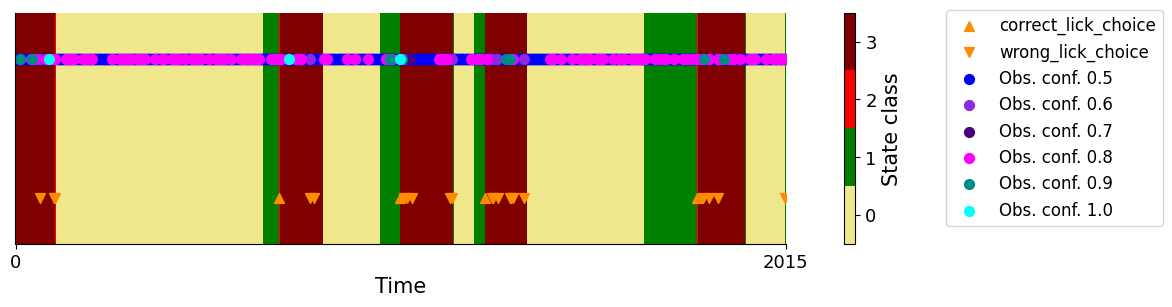

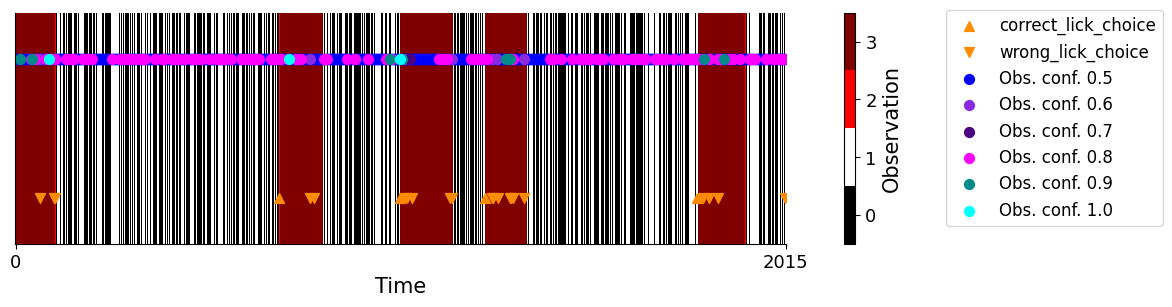

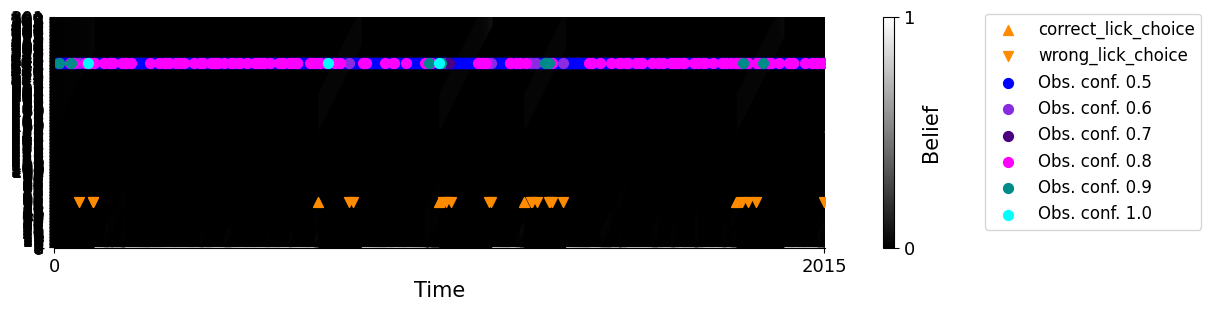

In [4]:
from auditoryforage.AF_env import AuditoryForaging

# Change below line if you want to try the trained model on a different set of environemnt.
# env_param = [-3.0, 8.0, 13, 8, -8, -4]

env = AuditoryForaging(spec={'agent':{'lick_cost':env_param[0],'food_reward':env_param[1],'attention_cost_coeff':env_param[2], 'attention_cost_temp': env_param[3], 'penalty_cost': env_param[4], 'iti_cost': env_param[5]}})
episode = agent.run_one_episode(env=env, num_steps=10000, q_states = [[i] for i in range(env.no_nodes)])
fig = plot_AF_episode(episode, env, agent, nodes_from_zero = 40, time_steps_before_lick = 20)

env.spec



In [5]:
from auditoryforage.utils import particle_filter
end_index = 200
no_particles = 500


state_list = [list_of_state[0] for list_of_state in episode['states']]
lick_actions = [env.dict_action_possible[action][0] for action in episode['actions']]

state_list = state_list[:end_index]
lick_actions = lick_actions[:end_index]

action_list, observation_list, belief_list, likelihood_list = particle_filter(agent = agent, env = env, lick_actions = lick_actions, state_list = state_list, no_particles = no_particles, sampling_freq = 1)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
Error: Mistake in belief update as all probabilities are coming out to be 0 somehow. Returned zero!
124
125
126
Error: Mistake in belief update as all probabilities are coming out to be 0 somehow. Returned zero!
127
128
129
Error: Mistake in belief update as all probabilities are coming out to be 0 somehow. Returned zero!
130
131
132
Error: Mistake in belief update as all probabilities are coming out to be 0 somehow. Returned zero!
133
134
135
136
Error: Mistake in belief update as all probabilities are coming out to be 0 somehow. Returned zero!
137
138
Error: Mistake in belief update as all probabilities a

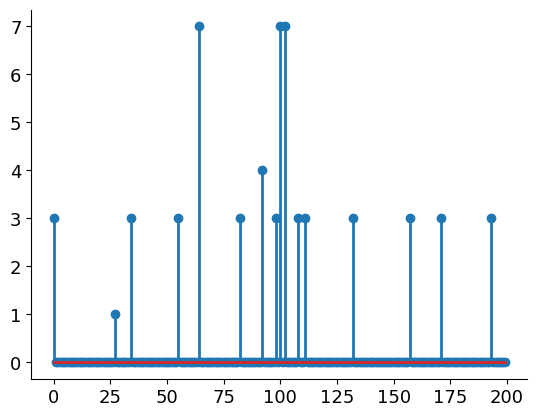

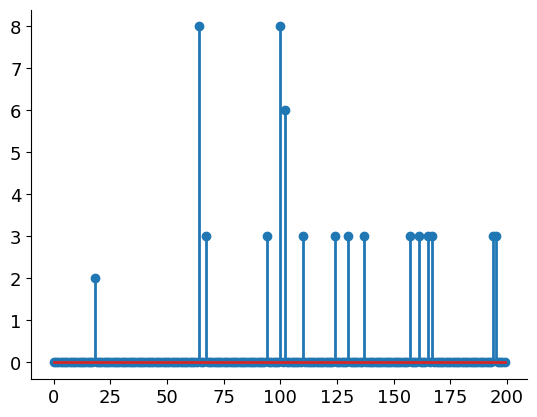

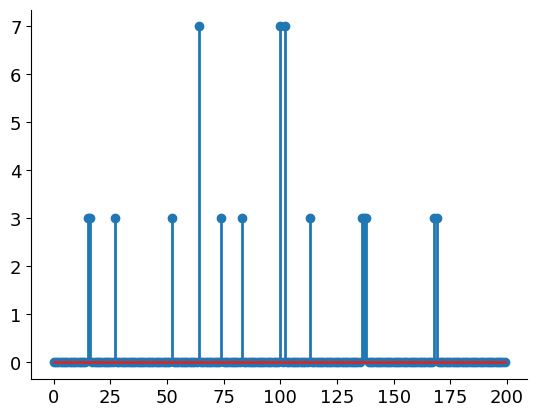

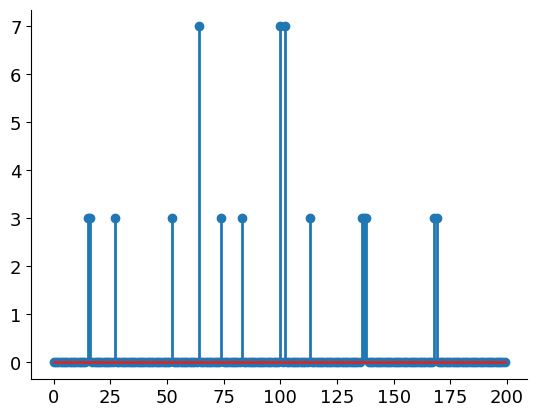

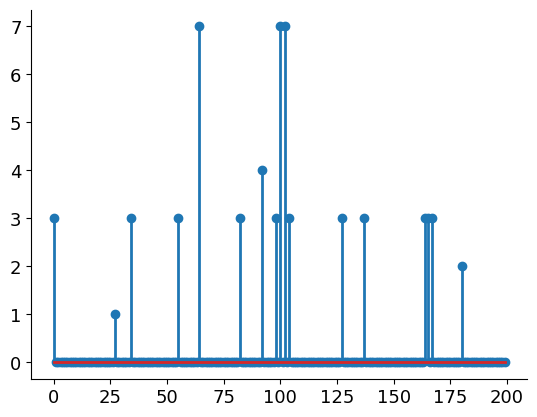

In [17]:
# action_list, observation_list, belief_list, likelihood_list
# plt.stem([int(action) for action in action_list])
for particle in range(5):
    plt.figure()
    plt.stem(action_list[particle])
    plt.show()

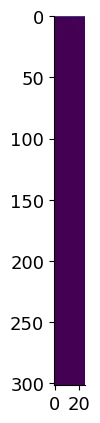

In [19]:
for particle in range(1):
    plt.figure()
    plt.imshow(np.array(belief_list[particle]).T[:,125:150])
    plt.show()

In [15]:
print(np.array(belief_list[particle]).T[:,100:150])

[[0.         0.         0.         ... 0.92419175 0.92049498 0.916813  ]
 [0.         0.         0.         ... 0.00371161 0.00369677 0.00368198]
 [0.         0.         0.         ... 0.00372652 0.00371161 0.00369677]
 ...
 [0.02       0.02040816 0.02083333 ... 0.         0.         0.        ]
 [0.02       0.02040816 0.02083333 ... 0.         0.         0.        ]
 [0.02       0.02040816 0.02083333 ... 0.         0.         0.        ]]


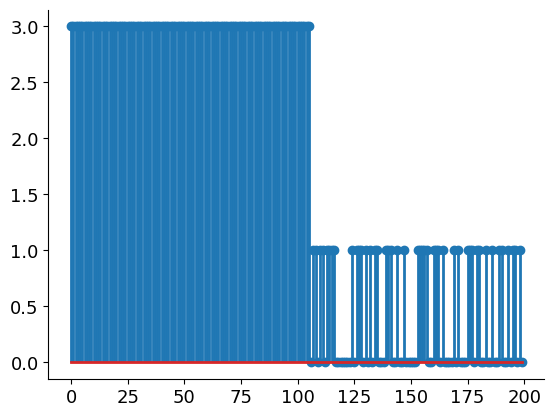

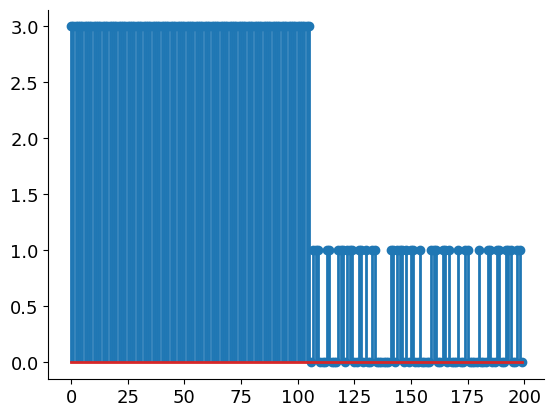

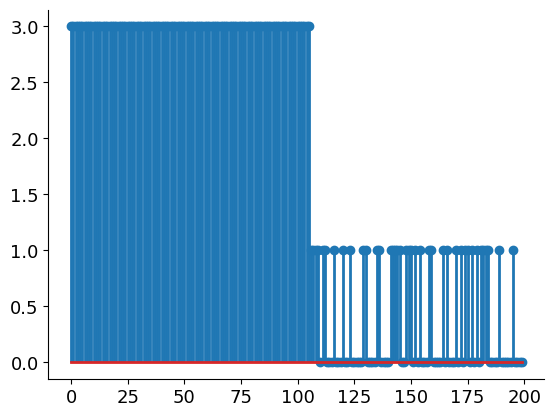

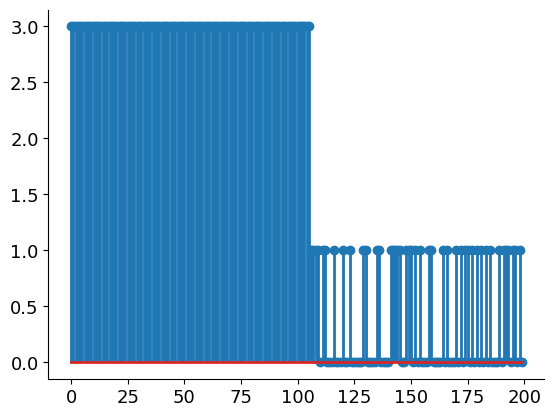

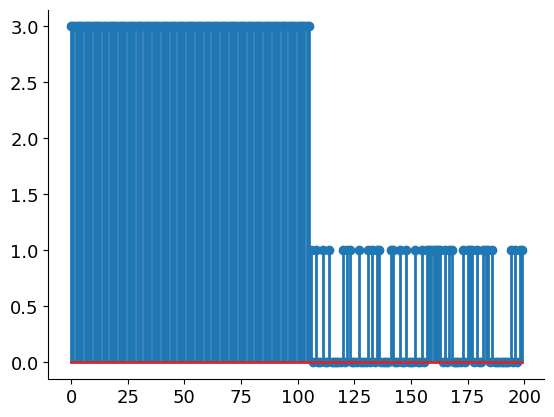

In [16]:
# action_list, observation_list, belief_list, likelihood_list
for particle in range(5):
    plt.figure()
    plt.stem(observation_list[particle])
    plt.show()

In [ ]:
observation_list[0]